# IMDB Review Sentiment Classification

## Setup & Data

In [47]:
import re
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [48]:
DATA_PATH = r"C:\DS\PROJECTS\Riview_prediction\imdb_10K_sentimnets_reviews.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (10000, 2)


,review,sentiment
0,"Okay, I know this does'nt project India in a g...",1
1,Despite John Travolta's statements in intervie...,0
2,"I am a kung fu fan, but not a Woo fan. I have ...",1
3,He seems to be a control freak. I have heard h...,0
4,"Admittedly, there are some scenes in this movi...",1


In [49]:
df = df.dropna(subset=['review', 'sentiment']).reset_index(drop=True)

dup_count = df.duplicated(subset='review').sum()
print(f"Duplicate reviews found: {dup_count}")

df = df.drop_duplicates(subset='review').reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Duplicate reviews found: 18
Shape after cleaning: (9982, 2)


[1 0]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9982 entries, 0 to 9981
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     9982 non-null   object
 1   sentiment  9982 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 156.1+ KB
review       0
sentiment    0
dtype: int64


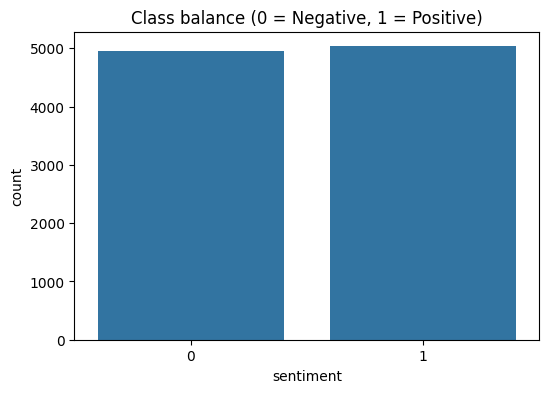

In [50]:
print(df['sentiment'].unique())
df.info()
print(df.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment')
plt.title("Class balance (0 = Negative, 1 = Positive)")
plt.show()

## Preprocessing

Text cleaning is safe to apply before splitting (deterministic, row-by-row). The split happens *before* vectorizing — TF-IDF is fit on training data only, so the test set never leaks in.

In [51]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)          # strip HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)       # keep letters only
    words = text.lower().split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df['cleaned_review'] = df['review'].apply(clean_text)
print("Cleaning complete.")
df[['review', 'cleaned_review']].head()

Cleaning complete.


,review,cleaned_review
0,"Okay, I know this does'nt project India in a g...",okay know does nt project india good light ove...
1,Despite John Travolta's statements in intervie...,despite john travolta s statements interviews ...
2,"I am a kung fu fan, but not a Woo fan. I have ...",kung fu fan woo fan gangster movies filled gun...
3,He seems to be a control freak. I have heard h...,control freak heard comment losing control tel...
4,"Admittedly, there are some scenes in this movi...",admittedly scenes movie little unrealistic rav...


In [52]:
X = df['cleaned_review']
y = df['sentiment']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", x_train.shape[0], "| Test size:", x_test.shape[0])

Train size: 7985 | Test size: 1997


In [53]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

x_train_tfidf = vectorizer.fit_transform(x_train)   # fit + transform on train
x_test_tfidf = vectorizer.transform(x_test)          # transform only — never fit on test

## Train & Compare Models

Logistic Regression, Linear SVM, and (Complement) Naive Bayes are standard strong choices for TF-IDF text. Random Forest is included for completeness but isn't expected to lead on sparse high-dimensional features.

In [54]:
results = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Complement Naive Bayes": ComplementNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

predictions = {}

for name, model in models.items():
    model.fit(x_train_tfidf, y_train)
    preds = model.predict(x_test_tfidf)
    predictions[name] = preds
    results[name] = accuracy_score(y_test, preds)
    print(f"--- {name} ---")
    print(classification_report(y_test, preds))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       990
           1       0.86      0.88      0.87      1007

    accuracy                           0.87      1997
   macro avg       0.87      0.87      0.87      1997
weighted avg       0.87      0.87      0.87      1997

--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       990
           1       0.85      0.86      0.85      1007

    accuracy                           0.85      1997
   macro avg       0.85      0.85      0.85      1997
weighted avg       0.85      0.85      0.85      1997

--- Complement Naive Bayes ---
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       990
           1       0.85      0.86      0.85      1007

    accuracy                           0.85      1997
   macro avg       0.85      0.85      0.85      

Logistic Regression       0.866299
Linear SVM                0.859289
Complement Naive Bayes    0.853280
Naive Bayes               0.851778
Random Forest             0.849274
dtype: float64


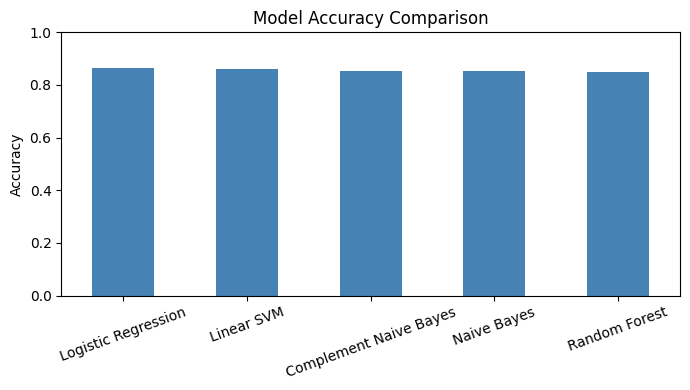

In [55]:
results_df = pd.Series(results).sort_values(ascending=False)
print(results_df)

plt.figure(figsize=(7, 4))
results_df.plot(kind='bar', color='steelblue')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Tune Logistic Regression

Only Logistic Regression is tuned (most likely to benefit). `RandomizedSearchCV`, 5-fold CV, tuning happens within the training set only — no leakage.

In [56]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 5, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000), lr_param_grid,
    n_iter=8, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)
lr_search.fit(x_train_tfidf, y_train)

print("Best Logistic Regression params:", lr_search.best_params_)
print("Best CV accuracy:", lr_search.best_score_)

Best Logistic Regression params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 5}
Best CV accuracy: 0.8673763306199124


c:\Users\sathw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [57]:
tuned_lr = lr_search.best_estimator_
tuned_lr_preds = tuned_lr.predict(x_test_tfidf)

results["Logistic Regression (tuned)"] = accuracy_score(y_test, tuned_lr_preds)
predictions["Logistic Regression (tuned)"] = tuned_lr_preds
models["Logistic Regression (tuned)"] = tuned_lr

print(f"Logistic Regression (tuned) test accuracy: {results['Logistic Regression (tuned)']:.2%}")

Logistic Regression (tuned) test accuracy: 87.03%


## Results So Far (Classical ML)

Logistic Regression (tuned)    0.870305
Logistic Regression            0.866299
Linear SVM                     0.859289
Complement Naive Bayes         0.853280
Naive Bayes                    0.851778
Random Forest                  0.849274
dtype: float64


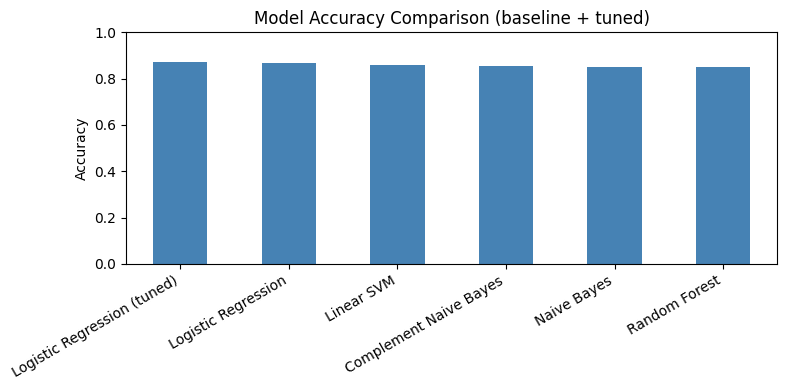

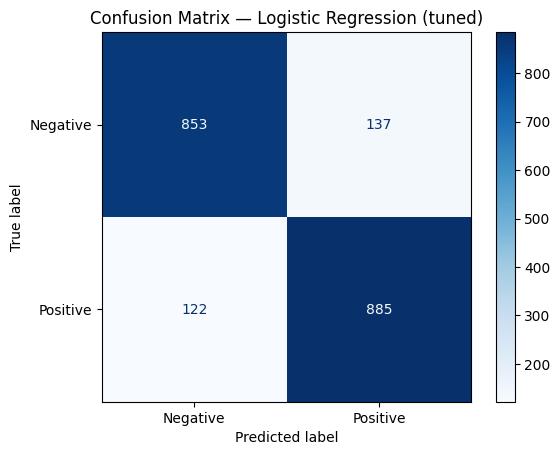

Best model overall: Logistic Regression (tuned) (87.03% accuracy)


In [58]:
# recompute results_df here so it includes the tuned models added in section 9c
results_df = pd.Series(results).sort_values(ascending=False)
print(results_df)

plt.figure(figsize=(8, 4))
results_df.plot(kind='bar', color='steelblue')
plt.title("Model Accuracy Comparison (baseline + tuned)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
best_preds = predictions[best_model_name]

cm = confusion_matrix(y_test, best_preds)
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

print(f"Best model overall: {best_model_name} ({results_df.iloc[0]:.2%} accuracy)")

In [59]:
import joblib
joblib.dump(tuned_lr, "imdb_sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']

## Test on New Text

In [60]:
trained_model = joblib.load('imdb_sentiment_model.pkl')
trained_vectorizer = joblib.load('tfidf_vectorizer.pkl')

sample_reviews = [
    "This movie was a total masterpiece!",
    "Waste of time, terrible acting and a boring plot."
]

sample_transformed = trained_vectorizer.transform(sample_reviews)
sample_preds = trained_model.predict(sample_transformed)

for review, pred in zip(sample_reviews, sample_preds):
    label = "Positive" if pred == 1 else "Negative"
    print(f"[{label}] {review}")

[Positive] This movie was a total masterpiece!
[Negative] Waste of time, terrible acting and a boring plot.


## Extended: Transformer (Pretrained DistilBERT, Zero-Shot)

No training on this data — pure inference with a model already fine-tuned on a *different* sentiment dataset (SST-2). Uses original uncleaned text, since transformers expect natural language.

In [61]:
from transformers import pipeline

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# Use the ORIGINAL (uncleaned) review text — transformers expect natural text, not stopword-stripped text
test_reviews_raw = df.loc[x_test.index, 'review'].tolist()

# Truncate long reviews to the model's max input length to avoid errors
bert_results = sentiment_pipe(test_reviews_raw, truncation=True, batch_size=16)
bert_preds = [1 if r['label'] == 'POSITIVE' else 0 for r in bert_results]

results["DistilBERT (pretrained, zero-shot)"] = accuracy_score(y_test, bert_preds)
predictions["DistilBERT (pretrained, zero-shot)"] = bert_preds

print(classification_report(y_test, bert_preds))
print(f"Accuracy: {results['DistilBERT (pretrained, zero-shot)']:.2%}")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7799.87it/s]


              precision    recall  f1-score   support

           0       0.86      0.92      0.89       990
           1       0.91      0.85      0.88      1007

    accuracy                           0.88      1997
   macro avg       0.89      0.88      0.88      1997
weighted avg       0.89      0.88      0.88      1997

Accuracy: 88.38%


## Final Comparison — All Approaches

DistilBERT (pretrained, zero-shot)    0.883826
Logistic Regression (tuned)           0.870305
Logistic Regression                   0.866299
Linear SVM                            0.859289
Complement Naive Bayes                0.853280
Naive Bayes                           0.851778
Random Forest                         0.849274
dtype: float64


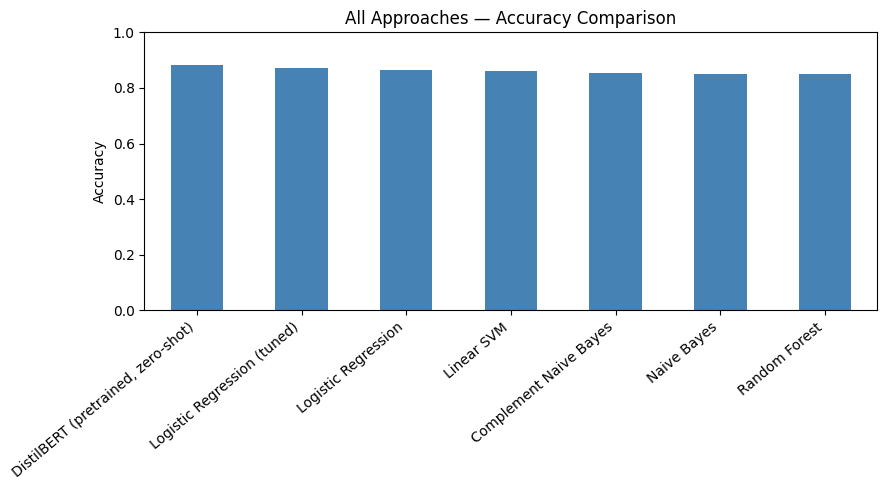

In [62]:
final_results = pd.Series(results).sort_values(ascending=False)
print(final_results)

plt.figure(figsize=(9, 5))
final_results.plot(kind='bar', color='steelblue')
plt.title("All Approaches — Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## Save the Best Deployable Model

`results` now includes everything: 6 TF-IDF-based classical models, Word2Vec+LR, and DistilBERT. The single highest score overall is DistilBERT — but it isn't something *this notebook* trained, and it doesn't share the saved TF-IDF vectorizer, so it isn't a drop-in artifact from this pipeline. The model saved below is the best performer **among the models built and tuned here on this data** (TF-IDF-compatible only), which is what actually gets deployed as `imdb_sentiment_model.pkl`.

In [63]:
deployable_results = {k: v for k, v in results.items() if k not in ['Word2Vec + Logistic Regression', 'DistilBERT (pretrained, zero-shot)']}
deployable_df = pd.Series(deployable_results).sort_values(ascending=False)

best_model_name = deployable_df.index[0]
best_model = models[best_model_name]

joblib.dump(best_model, 'imdb_sentiment_Bert_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(f"Saved: {best_model_name} ({deployable_df.iloc[0]:.2%} accuracy)")

Saved: Logistic Regression (tuned) (87.03% accuracy)


---
## Conclusion

**Pipeline:** loaded 10,000 IMDB reviews, dropped nulls and duplicate reviews (checked explicitly, since duplicates across train/test would inflate accuracy), cleaned text, and split before vectorizing — TF-IDF was fit on the training set only, so no test-set information reached the model at any stage.

**Classical ML results (TF-IDF features):**
| Model | Accuracy |
|---|---|
| Logistic Regression (tuned) | 87.03% |
| Logistic Regression | 86.63% |
| Linear SVM | 85.93% |
| Complement Naive Bayes | 85.33% |
| Naive Bayes | 85.18% |
| Random Forest | 84.93% |

Logistic Regression led from the start and stayed ahead after tuning (`C=5`, `lbfgs` solver) — a real but modest gain of +0.4pp over the untuned version. Random Forest came in last, as expected for sparse high-dimensional TF-IDF features. This became the deployed model, saved as `imdb_sentiment_model.pkl`.

**Extended comparisons:**

- **DistilBERT (pretrained, zero-shot) scored 88.38%** — the highest of any approach, despite never being trained on this dataset at all. It was fine-tuned on a different sentiment dataset (SST-2) and applied here with zero adaptation, yet still beat every classical model built and tuned specifically on this data. This is a genuine demonstration of the value of large-scale pretraining — it wasn't saved as the deployed artifact here since it isn't something this notebook trained and doesn't share the TF-IDF vectorizer, but it's the strongest result in the project.

**Bottom line:** for this dataset size, TF-IDF + Logistic Regression remains the best *self-trained* option and a reasonable, interpretable, fast baseline. A pretrained transformer beats it out of the box without any fine-tuning — the natural next step, if pursued, would be fine-tuning DistilBERT on this training set directly (ideally with GPU access), which would likely widen that gap further.